# Классификация эмоций: Нейтральная vs Ненейтральная

Сравниваем четыре подхода на объединённом датасете **RAVDESS + CREMA-D**:
1. **DistilHuBERT → Linear Classifier** — замороженный предобученный аудио-энкодер + линейный классификатор
2. **Log-Mel Spectrogram → CNN** — 2D-свёрточная сеть на спектрограммах
3. **MFCC → SVM** — классический ML-подход
4. **Wav2Vec2 (frozen) → MLP** — предобученный backbone полностью заморожен, обучается только MLP-голова поверх pooled-эмбеддингов

Метрики сравнения:
- **Качество** — Accuracy, F1 (macro), Precision, Recall
- **Скорость** — время инференса на одном файле (end-to-end)
- **Размер модели** — объём классификатора и всего пайплайна

In [1]:
import os, io, pickle, random, time, gc

import librosa
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import lightning as L

from transformers import AutoModel, Wav2Vec2FeatureExtractor, set_seed

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, classification_report,
)

from audiomentations import (
    Compose, AddGaussianSNR, Shift, Gain, TimeStretch, PitchShift,
)

import warnings
warnings.filterwarnings("ignore")


In [2]:
SEED = 42


def seed_everything(seed: int) -> None:
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    try:
        if torch.backends.mps.is_available():
            torch.mps.manual_seed(seed)
    except AttributeError:
        pass
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    set_seed(seed)


seed_everything(SEED)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}")
print(f"Random seed: {SEED}")

results = {}

Device: mps
Random seed: 42


In [3]:
def pytorch_size_mb(model):
    b = sum(p.numel() * p.element_size() for p in model.parameters())
    b += sum(x.numel() * x.element_size() for x in model.buffers())
    return b / 1024 ** 2


def sklearn_size_mb(model):
    buf = io.BytesIO()
    pickle.dump(model, buf)
    return buf.tell() / 1024 ** 2


CKPT_DIR = os.path.join("..", "trained_models", "audio_neutral")
os.makedirs(CKPT_DIR, exist_ok=True)


def save_state_dict(name, module):
    """Сохраняем чекпоинт сразу после обучения, чтобы освободить MPS."""
    path = os.path.join(CKPT_DIR, f"{name}.pt")
    cpu_state = {k: v.detach().cpu().clone() for k, v in module.state_dict().items()}
    torch.save(cpu_state, path)
    print(f"Saved {path}")


def save_sklearn(name, obj):
    path = os.path.join(CKPT_DIR, f"{name}.pkl")
    with open(path, "wb") as f:
        pickle.dump(obj, f)
    print(f"Saved {path}")


def free_mps():
    """Полная очистка MPS: gc + два прохода empty_cache."""
    gc.collect()
    if torch.backends.mps.is_available():
        torch.mps.empty_cache()
        torch.mps.synchronize()
        torch.mps.empty_cache()


## Загрузка данных RAVDESS + CREMA-D

In [4]:
RAVDESS_PATH = "../datasets/ravdess/"
SAMPLE_RATE_RAVDESS = 48000

file_paths, labels, speakers, sources = [], [], [], []

# ── RAVDESS ──
# Формат: 03-01-{emotion}-01-01-01-{actor}.wav  (emotion ≤ 2 - neutral)
audio_base = os.path.join(RAVDESS_PATH, "Audio_Speech_Actors_01-24")
for actor_dir in sorted(os.listdir(audio_base)):
    if not actor_dir.startswith("Actor_"):
        continue
    for f in sorted(os.listdir(os.path.join(audio_base, actor_dir))):
        if not f.endswith(".wav"):
            continue
        fp = os.path.join(audio_base, actor_dir, f)
        emotion = int(os.path.basename(f).split('-')[2])
        file_paths.append(fp)
        # 01 = neutral, 02 = calm, 03 = happy, 04 = sad, 05 = angry, 06 = fearful, 07 = disgust, 08 = surprised
        labels.append(0 if emotion <= 2 else 1)
        speakers.append(f"rav_{actor_dir.split('_')[1]}")
        sources.append("RAVDESS")

n_rav = len(file_paths)
print("RAVDESS: ", n_rav)

RAVDESS:  1440


In [5]:
CREMA_PATH = "../datasets/crema-d/"
SAMPLE_RATE_CREMAD = 16000
SR = SAMPLE_RATE_CREMAD # will be used as default

# ── CREMA-D ──
# Формат: {actorID}_{sentence}_{EMO}_{intensity}.wav  (NEU - neutral)
for f in sorted(os.listdir(CREMA_PATH)):
    if not f.endswith(".wav"):
        continue
    fp = os.path.join(CREMA_PATH, f)
    parts = f.replace(".wav", "").split("_")
    file_paths.append(fp)
    labels.append(0 if parts[2] == "NEU" else 1)
    speakers.append(f"crm_{parts[0]}")
    sources.append("CREMA-D")

n_crm = len(file_paths) - n_rav

labels = np.array(labels)
speakers = np.array(speakers)
sources = np.array(sources)

print("CREMA-D: ", n_crm)

CREMA-D:  7442


In [6]:
# Speaker-independent split: по 20 % спикеров из каждого датасета - test
test_speakers = set()
for ds in ["RAVDESS", "CREMA-D"]:
    ds_spk = sorted(set(speakers[sources == ds]))
    n_test = max(1, len(ds_spk) // 5)
    test_speakers.update(ds_spk[-n_test:])

train_idx = [i for i, s in enumerate(speakers) if s not in test_speakers]
test_idx  = [i for i, s in enumerate(speakers) if s in test_speakers]

train_files = [file_paths[i] for i in train_idx]
test_files  = [file_paths[i] for i in test_idx]
y_train, y_test = labels[train_idx], labels[test_idx]

print(f"RAVDESS: {n_rav} файлов | CREMA-D: {n_crm} файлов | Всего: {len(file_paths)}")
print(f"Neutral: {(labels==0).sum()} | Emotional: {(labels==1).sum()}")
print(f"\nSpeaker-independent split (20 % спикеров из каждого датасета):")
print(f"  Train: {len(train_files)} файлов ({len(set(speakers[train_idx]))} спикеров)")
print(f"  Test:  {len(test_files)} файлов ({len(test_speakers)} спикеров)")
print(f"  Train balance — neutral: {(y_train==0).sum()}, emotional: {(y_train==1).sum()}")
print(f"  Test  balance — neutral: {(y_test==0).sum()}, emotional: {(y_test==1).sum()}")

RAVDESS: 1440 файлов | CREMA-D: 7442 файлов | Всего: 8882
Neutral: 1375 | Emotional: 7507

Speaker-independent split (20 % спикеров из каждого датасета):
  Train: 7167 файлов (93 спикеров)
  Test:  1715 файлов (22 спикеров)
  Train balance — neutral: 1112, emotional: 6055
  Test  balance — neutral: 263, emotional: 1452


In [7]:
def load_audio(path):
    y, sr = librosa.load(path, sr=None)
    if sr != SR:
        y = librosa.resample(y, orig_sr=sr, target_sr=SR)
    return y

train_files_loaded = [load_audio(f) for f in train_files]
test_files_loaded = [load_audio(f) for f in test_files]


In [8]:
# Аугментации обучающего набора (offline expansion, K=3 копий на запись).
# Тест не аугментируется. Каждая копия независимо сэмплирует параметры
# (фон-шум, time-shift, gain, time-stretch, pitch-shift).
AUG_COPIES = 3

augmenter = Compose([
    AddGaussianSNR(min_snr_db=5.0, max_snr_db=25.0, p=0.6),
    Shift(min_shift=-1.0, max_shift=1.0, shift_unit="seconds", rollover=False, p=0.5),
    Gain(min_gain_db=-9.0, max_gain_db=6.0, p=0.5),
    TimeStretch(min_rate=0.9, max_rate=1.1, leave_length_unchanged=True, p=0.4),
    PitchShift(min_semitones=-2, max_semitones=2, p=0.4),
])

random.seed(SEED)
np.random.seed(SEED)

train_files_orig = train_files_loaded
y_train_orig = y_train

train_files_aug = list(train_files_orig)
y_train_aug = list(y_train_orig)
for k in range(AUG_COPIES):
    for wav, lbl in tqdm(
        zip(train_files_orig, y_train_orig),
        total=len(train_files_orig),
        desc=f"Аугментация (копия {k+1}/{AUG_COPIES})",
    ):
        aug = augmenter(samples=wav.astype(np.float32), sample_rate=SR)
        train_files_aug.append(aug)
        y_train_aug.append(lbl)

train_files_loaded = train_files_aug
y_train = np.asarray(y_train_aug, dtype=y_train_orig.dtype)

assert len(train_files_loaded) == (1 + AUG_COPIES) * len(train_files_orig)
assert len(y_train) == len(train_files_loaded)
print(
    f"Train после аугментации: {len(train_files_loaded)} клипов "
    f"({1 + AUG_COPIES}× оригинала). "
    f"Neutral: {(y_train==0).sum()} | Emotional: {(y_train==1).sum()}"
)


Аугментация (копия 3/3): 100%|██████████| 7167/7167 [00:34<00:00, 207.20it/s]

Train после аугментации: 28668 клипов (4× оригинала). Neutral: 4448 | Emotional: 24220


## Подход 1: audio → DistilHuBERT → Linear Classifier

In [9]:
HUBERT_NAME = "ntu-spml/distilhubert"
hub_extractor = Wav2Vec2FeatureExtractor.from_pretrained(HUBERT_NAME)
hub_model = AutoModel.from_pretrained(HUBERT_NAME).to(device).eval()

Loading weights:   0%|          | 0/49 [00:00<?, ?it/s]

In [10]:
hub_dim = hub_model.config.hidden_size
hub_params = sum(p.numel() for p in hub_model.parameters())
print(f"DistilHuBERT: hidden_size={hub_dim}, params={hub_params:,}")


def hubert_embed(index, train=True):
    file = train_files_loaded[index] if train else test_files_loaded[index]
    inp = hub_extractor(file, sampling_rate=SR, return_tensors="pt").to(device)
    with torch.no_grad():
        h = hub_model(**inp).last_hidden_state  # (1, T, hidden_size)
    if train:
        return h.mean(dim=1).squeeze(0).cpu().numpy()  # (hidden_size,)
    return h.mean(dim=1)

print("Извлечение DistilHuBERT-эмбеддингов...")
start_time = time.time()
X_hub_train = np.array([hubert_embed(index) for index in tqdm(range(len(train_files_loaded)))])
extract_time = time.time() - start_time


DistilHuBERT: hidden_size=768, params=23,491,968
Извлечение DistilHuBERT-эмбеддингов...


100%|██████████| 28668/28668 [07:28<00:00, 63.91it/s]


In [11]:
X_hub_test  = [hubert_embed(index, train=False) for index in tqdm(range(len(test_files)))]
print(f"Train: {X_hub_train.shape}, Test: {len(X_hub_test)}")

100%|██████████| 1715/1715 [00:25<00:00, 67.71it/s]

Train: (28668, 768), Test: 1715


In [12]:
class LinearClassifier(nn.Module):
    def __init__(self, d, n_classes=2):
        super().__init__()
        self.fc = nn.Linear(d, n_classes)

    def forward(self, x):
        return self.fc(x)


class LinearModule(L.LightningModule):
    def __init__(self, d, X_train, y_train, X_test, y_test, epochs):
        super().__init__()
        self.model = LinearClassifier(d)
        self._xt = torch.tensor(X_train, dtype=torch.float32)
        self._y = y_train
        self._X_test = X_test
        self._y_test = y_test
        self._epochs = epochs
        self._last_loss = None

    def training_step(self, batch, _):
        xb, yb = batch
        self._last_loss = F.cross_entropy(self.model(xb), yb)
        return self._last_loss

    def on_train_epoch_end(self):
        ep = self.current_epoch
        if (ep + 1) % 10 != 0:
            return
        with torch.no_grad():
            train_acc = (
                self.model(self._xt.to(self.device)).argmax(1).cpu().numpy() == self._y
            ).mean()
            preds = [self.model(x.to(self.device)).argmax(1).item() for x in self._X_test]
        test_acc = accuracy_score(self._y_test, preds)
        test_f1 = f1_score(self._y_test, preds, average="macro")
        loss_val = self._last_loss.item() if self._last_loss is not None else float("nan")
        print(f"Epoch {ep+1}/{self._epochs} | Loss {loss_val:.4f} | Train Acc {train_acc:.4f}")
        print(f"Test Acc {test_acc:.4f}, F1 {test_f1:.4f}")

    def configure_optimizers(self):
        return optim.Adam(self.parameters(), lr=1e-3, weight_decay=1e-4)


EPOCHS = 200
ds1 = TensorDataset(
    torch.tensor(X_hub_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.long),
)
loader1 = DataLoader(
    ds1,
    batch_size=32,
    shuffle=True,
    generator=torch.Generator().manual_seed(SEED),
)

module_1 = LinearModule(hub_dim, X_hub_train, y_train, X_hub_test, y_test, EPOCHS)
trainer_1 = L.Trainer(
    max_epochs=EPOCHS,
    accelerator="auto",
    enable_progress_bar=False,
    logger=False,
    enable_checkpointing=False,
)
t0 = time.time()
trainer_1.fit(module_1, loader1)
train_time_1 = time.time() - t0

model_1 = module_1.model.to(device)

# Сохраняем чекпоинт сразу после обучения
save_state_dict("linear_classifier", model_1)

# End-to-end инференс
model_1.eval()
t0 = time.time()
preds_1 = []
for test_index in tqdm(range(len(test_files))):
    y_audio = test_files_loaded[test_index]
    inp = hub_extractor(y_audio, sampling_rate=SR, return_tensors="pt").to(device)
    with torch.no_grad():
        emb = hub_model(**inp).last_hidden_state.mean(dim=1)
        preds_1.append(model_1(emb).argmax(1).item())
inf_time_1 = (time.time() - t0) / len(test_files)
preds_1 = np.array(preds_1)

hub_pipeline_mb = pytorch_size_mb(hub_model) + pytorch_size_mb(model_1)
cls_1_mb = pytorch_size_mb(model_1)

results['DistilHuBERT_Linear'] = {
    "Модель": "DistilHuBERT + Linear",
    "Accuracy": accuracy_score(y_test, preds_1),
    "F1 (macro)": f1_score(y_test, preds_1, average="macro"),
    "Precision": precision_score(y_test, preds_1, average="macro", zero_division=0),
    "Recall": recall_score(y_test, preds_1, average="macro", zero_division=0),
    "Инференс (мс/файл)": inf_time_1 * 1000,
    "Обучение (сек)": extract_time + train_time_1,
    "Классификатор (MB)": cls_1_mb,
    "Пайплайн (MB)": hub_pipeline_mb,
}
print(f"\nDistilHuBERT + Linear - Acc={results['DistilHuBERT_Linear']['Accuracy']:.4f} "
      f"F1={results['DistilHuBERT_Linear']['F1 (macro)']:.4f} "
      f"Inf={inf_time_1*1000:.1f} мс/файл  Pipeline={hub_pipeline_mb:.1f} MB")

# Полная очистка: backbone, тяжёлые признаки и Lightning-объекты
hub_model.cpu()
model_1.cpu()
del hub_model, hub_extractor, module_1, trainer_1, ds1, loader1
del X_hub_train, X_hub_test
free_mps()


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ LinearClassifier │  1.5 K │ train │     0 │
└───┴───────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 1.5 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.5 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 2                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Epoch 10/200 | Loss 0.3124 | Train Acc 0.9036
Test Acc 0.8571, F1 0.7730
Epoch 20/200 | Loss 0.1546 | Train Acc 0.9064
Test Acc 0.8834, F1 0.8065
Epoch 30/200 | Loss 0.2679 | Train Acc 0.9107
Test Acc 0.8741, F1 0.7978
Epoch 40/200 | Loss 0.1725 | Train Acc 0.9083
Test Acc 0.9032, F1 0.8310
Epoch 50/200 | Loss 0.2436 | Train Acc 0.9154
Test Acc 0.8787, F1 0.8026
Epoch 60/200 | Loss 0.1751 | Train Acc 0.9130
Test Acc 0.8898, F1 0.8160
Epoch 70/200 | Loss 0.2586 | Train Acc 0.9181
Test Acc 0.8863, F1 0.8129
Epoch 80/200 | Loss 0.2895 | Train Acc 0.9159
Test Acc 0.9015, F1 0.8304
Epoch 90/200 | Loss 0.2132 | Train Acc 0.9194
Test Acc 0.8816, F1 0.8067
Epoch 100/200 | Loss 0.1258 | Train Acc 0.9197
Test Acc 0.8822, F1 0.8105
Epoch 110/200 | Loss 0.1127 | Train Acc 0.9169
Test Acc 0.8869, F1 0.8132
Epoch 120/200 | Loss 0.1207 | Train Acc 0.9183
Test Acc 0.8886, F1 0.8141
Epoch 130/200 | Loss 0.3030 | Train Acc 0.9131
Test Acc 0.9067, F1 0.8371
Epoch 140/200 | Loss 0.1583 | Train Acc 0.9194


`Trainer.fit` stopped: `max_epochs=200` reached.


Epoch 200/200 | Loss 0.1684 | Train Acc 0.9150
Test Acc 0.9044, F1 0.8348
Saved ../trained_models/audio_neutral/linear_classifier.pt


100%|██████████| 1715/1715 [00:25<00:00, 66.55it/s]



DistilHuBERT + Linear - Acc=0.9044 F1=0.8348 Inf=15.0 мс/файл  Pipeline=89.6 MB


## Подход 2: audio → Log-Mel Spectrogram → CNN

In [13]:
N_MELS, MAX_LEN, HOP = 64, 128, 512


def extract_log_mel(index, train=True):
    y = train_files_loaded[index] if train else test_files_loaded[index]
    mel = librosa.feature.melspectrogram(y=y, sr=SR, n_mels=N_MELS, hop_length=HOP)
    lm = librosa.power_to_db(mel, ref=np.max)
    if lm.shape[1] < MAX_LEN:
        lm = np.pad(lm, ((0, 0), (0, MAX_LEN - lm.shape[1])))
    else:
        lm = lm[:, :MAX_LEN]
    return lm  # (N_MELS, MAX_LEN)


print("Извлечение log-mel спектрограмм...")
extract_start = time.time()
X_mel_train = np.array([extract_log_mel(index) for index in tqdm(range(len(train_files_loaded)))])
extract_time = time.time() - extract_start
X_mel_test  = np.array([extract_log_mel(index, train=False) for index in tqdm(range(len(test_files_loaded)))])

mel_mean, mel_std = X_mel_train.mean(), X_mel_train.std()
X_mel_train = (X_mel_train - mel_mean) / (mel_std + 1e-8)
X_mel_test  = (X_mel_test  - mel_mean) / (mel_std + 1e-8)
print(f"Train: {X_mel_train.shape}, Test: {X_mel_test.shape}")


Извлечение log-mel спектрограмм...


100%|██████████| 1715/1715 [00:02<00:00, 713.51it/s]


Train: (28668, 64, 128), Test: (1715, 64, 128)


In [16]:
class MelCNN(nn.Module):
    def __init__(self, n_mels=64, max_len=128):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * (n_mels // 8) * (max_len // 8), 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 2),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


def _chunked_predict(model, x_cpu, device, batch_size=64):
    """Инференс модели по тензору, разбитому на батчи на CPU,
    чтобы не аллоцировать на MPS активации сразу для всего набора."""
    model.eval()
    preds = []
    with torch.no_grad():
        for i in range(0, x_cpu.size(0), batch_size):
            xb = x_cpu[i : i + batch_size].to(device)
            preds.append(model(xb).argmax(1).cpu())
            del xb
    return torch.cat(preds).numpy()


class MelModule(L.LightningModule):
    def __init__(self, model, class_weights, X_train, y_train, X_test, y_test, epochs):
        super().__init__()
        self.model = model
        self.register_buffer("w", class_weights)
        self._xt = torch.tensor(X_train[:, None], dtype=torch.float32)
        self._y = y_train
        self._xt_test = torch.tensor(X_test[:, None], dtype=torch.float32)
        self._y_test = y_test
        self._epochs = epochs
        self._last_loss = None

    def training_step(self, batch, _):
        xb, yb = batch
        self._last_loss = F.cross_entropy(self.model(xb), yb, weight=self.w)
        return self._last_loss

    def on_train_epoch_end(self):
        ep = self.current_epoch
        if (ep + 1) % 5 != 0:
            return
        # Чанковый инференс — не загружаем весь train (4× после аугментации)
        # на MPS одновременно: активации Conv2d легко съедают десятки GB.
        train_preds = _chunked_predict(self.model, self._xt, self.device, batch_size=64)
        test_preds = _chunked_predict(self.model, self._xt_test, self.device, batch_size=64)
        self.model.train()
        acc = (train_preds == self._y).mean()
        test_acc = accuracy_score(self._y_test, test_preds)
        test_f1 = f1_score(self._y_test, test_preds, average="macro")
        loss_val = self._last_loss.item() if self._last_loss is not None else float("nan")
        lr = self.trainer.optimizers[0].param_groups[0]["lr"]
        print(
            f"Epoch {ep+1}/{self._epochs} | LR {lr:.2e} | Loss {loss_val:.4f} | Train Acc {acc:.4f} | "
            f"Test Acc {test_acc:.4f}, F1 {test_f1:.4f}"
        )
        free_mps()

    def configure_optimizers(self):
        opt = optim.Adam(self.model.parameters(), lr=1e-5, weight_decay=2e-6)
        sched = optim.lr_scheduler.CosineAnnealingLR(
            opt, T_max=self._epochs, eta_min=1e-7
        )
        return {
            "optimizer": opt,
            "lr_scheduler": {"scheduler": sched, "interval": "epoch"},
        }


In [18]:
n_neutral_train = (y_train == 0).sum()
n_emotional_train = (y_train == 1).sum()
n_total_train = len(y_train)
class_weights = torch.tensor(
    [n_total_train / (2 * n_neutral_train), n_total_train / (2 * n_emotional_train)],
    dtype=torch.float32,
)
print(f"Class weights — Neutral: {class_weights[0]:.3f}, Emotional: {class_weights[1]:.3f}")

ds2 = TensorDataset(
    torch.tensor(X_mel_train[:, None], dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.long),
)
loader2 = DataLoader(
    ds2,
    batch_size=32,
    shuffle=True,
    generator=torch.Generator().manual_seed(SEED + 1),
)

model_2 = MelCNN(N_MELS, MAX_LEN).to(device)
print(f"CNN params: {sum(p.numel() for p in model_2.parameters()):,}")

EPOCHS = 50
module_2 = MelModule(model_2, class_weights, X_mel_train, y_train, X_mel_test, y_test, EPOCHS)
trainer_2 = L.Trainer(
    max_epochs=EPOCHS,
    accelerator="auto",
    enable_progress_bar=False,
    logger=False,
    enable_checkpointing=False,
)
t0 = time.time()
trainer_2.fit(module_2, loader2)
train_time_2 = time.time() - t0

model_2 = module_2.model.to(device)

# Сохраняем чекпоинт сразу после обучения
save_state_dict("mel_cnn", model_2)

# End-to-end инференс
model_2.eval()
t0 = time.time()
preds_2 = []
for index in tqdm(range(len(test_files))):
    y_audio = test_files_loaded[index]
    mel = librosa.feature.melspectrogram(y=y_audio, sr=SR, n_mels=N_MELS, hop_length=HOP)
    lm = librosa.power_to_db(mel, ref=np.max)
    if lm.shape[1] < MAX_LEN:
        lm = np.pad(lm, ((0, 0), (0, MAX_LEN - lm.shape[1])))
    else:
        lm = lm[:, :MAX_LEN]
    lm = (lm - mel_mean) / (mel_std + 1e-8)
    xt = torch.tensor(lm[None, None], dtype=torch.float32).to(device)
    with torch.no_grad():
        preds_2.append(model_2(xt).argmax(1).item())
inf_time_2 = (time.time() - t0) / len(test_files)
preds_2 = np.array(preds_2)

cls_2_mb = pytorch_size_mb(model_2)

results['Log-Mel_CNN'] = {
    "Модель": "Log-Mel + CNN",
    "Accuracy": accuracy_score(y_test, preds_2),
    "F1 (macro)": f1_score(y_test, preds_2, average="macro"),
    "Precision": precision_score(y_test, preds_2, average="macro", zero_division=0),
    "Recall": recall_score(y_test, preds_2, average="macro", zero_division=0),
    "Инференс (мс/файл)": inf_time_2 * 1000,
    "Обучение (сек)": extract_time + train_time_2,
    "Классификатор (MB)": cls_2_mb,
    "Пайплайн (MB)": cls_2_mb,
}
print(f"\nLog-Mel + CNN => Acc={results['Log-Mel_CNN']['Accuracy']:.4f} "
      f"F1={results['Log-Mel_CNN']['F1 (macro)']:.4f} "
      f"Inf={inf_time_2*1000:.1f} мс/файл  Size={cls_2_mb:.2f} MB")

# Полная очистка
model_2.cpu()
del module_2, trainer_2, ds2, loader2
del X_mel_train, X_mel_test
free_mps()


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Class weights — Neutral: 3.223, Emotional: 0.592
CNN params: 2,121,442


┏━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type   ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ MelCNN │  2.1 M │ train │     0 │
└───┴───────┴────────┴────────┴───────┴───────┘

Trainable params: 2.1 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.1 M                                                                                                
Total estimated model params size (MB): 8                                                                          
Modules in train mode: 20                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Epoch 5/50 | LR 9.76e-06 | Loss 0.3915 | Train Acc 0.7677 | Test Acc 0.7364, F1 0.6540
Epoch 10/50 | LR 9.05e-06 | Loss 0.3040 | Train Acc 0.7907 | Test Acc 0.7504, F1 0.6689
Epoch 15/50 | LR 7.96e-06 | Loss 0.1867 | Train Acc 0.8318 | Test Acc 0.7738, F1 0.6875
Epoch 20/50 | LR 6.58e-06 | Loss 0.3052 | Train Acc 0.8673 | Test Acc 0.7977, F1 0.7097
Epoch 25/50 | LR 5.05e-06 | Loss 0.2880 | Train Acc 0.8937 | Test Acc 0.8122, F1 0.7187
Epoch 30/50 | LR 3.52e-06 | Loss 0.1481 | Train Acc 0.8959 | Test Acc 0.8105, F1 0.7197
Epoch 35/50 | LR 2.14e-06 | Loss 0.1645 | Train Acc 0.9074 | Test Acc 0.8222, F1 0.7277
Epoch 40/50 | LR 1.05e-06 | Loss 0.2747 | Train Acc 0.9145 | Test Acc 0.8297, F1 0.7357
Epoch 45/50 | LR 3.42e-07 | Loss 0.1733 | Train Acc 0.9177 | Test Acc 0.8315, F1 0.7381


`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 50/50 | LR 1.00e-07 | Loss 0.2193 | Train Acc 0.9163 | Test Acc 0.8274, F1 0.7344
Saved ../trained_models/audio_neutral/mel_cnn.pt


100%|██████████| 1715/1715 [00:05<00:00, 292.86it/s]



Log-Mel + CNN => Acc=0.8274 F1=0.7344 Inf=3.4 мс/файл  Size=8.09 MB


## Подход 3: audio → MFCC → SVM

In [19]:
N_MFCC = 40


def extract_mfcc_stats(index, train=True):
    """MFCC + delta + delta2, агрегированные по времени (mean, std)."""
    y = train_files_loaded[index] if train else test_files_loaded[index]
    mfcc = librosa.feature.mfcc(y=y, sr=SR, n_mfcc=N_MFCC)
    d1 = librosa.feature.delta(mfcc)
    d2 = librosa.feature.delta(mfcc, order=2)
    return np.concatenate([
        mfcc.mean(1), mfcc.std(1),
        d1.mean(1),   d1.std(1),
        d2.mean(1),   d2.std(1),
    ])  # (N_MFCC * 6,) = (240,)


print("Извлечение MFCC-признаков...")
extract_start = time.time()
X_mfcc_train = np.array([extract_mfcc_stats(i) for i in tqdm(range(len(train_files_loaded)))])
extract_time = time.time() - extract_start
X_mfcc_test  = np.array([extract_mfcc_stats(i, train=False) for i in tqdm(range(len(test_files_loaded)))])

scaler = StandardScaler()
X_mfcc_train_s = scaler.fit_transform(X_mfcc_train)
X_mfcc_test_s  = scaler.transform(X_mfcc_test)
print(f"Feature dim: {X_mfcc_train_s.shape[1]}")

t0 = time.time()
model_3 = SVC(kernel="rbf", C=10, gamma="scale", random_state=SEED)
model_3.fit(X_mfcc_train_s, y_train)
train_time_3 = time.time() - t0
print(f"SVM обучен за {train_time_3:.1f} сек | "
      f"Train Acc: {model_3.score(X_mfcc_train_s, y_train):.4f}")

# Сохраняем сразу после обучения
save_sklearn("svm", model_3)
save_sklearn("svm_scaler", scaler)

# End-to-end инференс
t0 = time.time()
preds_3 = []
for i in range(len(test_files_loaded)):
    feat = extract_mfcc_stats(i, train=False)
    preds_3.append(model_3.predict(scaler.transform(feat.reshape(1, -1)))[0])
inf_time_3 = (time.time() - t0) / len(test_files_loaded)
preds_3 = np.array(preds_3)

svm_mb = sklearn_size_mb(model_3)
scaler_mb = sklearn_size_mb(scaler)

results['MFCC_SVM'] = {
    "Модель": "MFCC + SVM",
    "Accuracy": accuracy_score(y_test, preds_3),
    "F1 (macro)": f1_score(y_test, preds_3, average="macro"),
    "Precision": precision_score(y_test, preds_3, average="macro", zero_division=0),
    "Recall": recall_score(y_test, preds_3, average="macro", zero_division=0),
    "Инференс (мс/файл)": inf_time_3 * 1000,
    "Обучение (сек)": extract_time + train_time_3,
    "Классификатор (MB)": svm_mb,
    "Пайплайн (MB)": svm_mb + scaler_mb,
}
print(f"\nMFCC + SVM => Acc={results['MFCC_SVM']['Accuracy']:.4f} "
      f"F1={results['MFCC_SVM']['F1 (macro)']:.4f} "
      f"Inf={inf_time_3*1000:.1f} мс/файл  Size={svm_mb:.2f} MB")

del X_mfcc_train, X_mfcc_test, X_mfcc_train_s, X_mfcc_test_s
free_mps()


Извлечение MFCC-признаков...


100%|██████████| 1715/1715 [00:04<00:00, 427.45it/s]


Feature dim: 240
SVM обучен за 328.3 сек | Train Acc: 0.9964
Saved ../trained_models/audio_neutral/svm.pkl
Saved ../trained_models/audio_neutral/svm_scaler.pkl

MFCC + SVM => Acc=0.7749 F1=0.6379 Inf=4.5 мс/файл  Size=21.46 MB


## Подход 4: audio → Wav2Vec2 (frozen) → Linear Classifier

Используем предобученный `facebook/wav2vec2-base` как замороженный экстрактор признаков; обучаем только голову `Linear(768→256)→ReLU→Dropout(0.3)→Linear(256→2)`.

In [31]:
from transformers import Wav2Vec2Model
from torch.utils.data import Dataset

W2V_NAME = "facebook/wav2vec2-base"
MAX_AUDIO_SEC = 6
MAX_AUDIO_LEN = MAX_AUDIO_SEC * SR

w2v_extractor = Wav2Vec2FeatureExtractor.from_pretrained(W2V_NAME)
w2v_backbone = Wav2Vec2Model.from_pretrained(W2V_NAME)
if hasattr(w2v_backbone, "gradient_checkpointing_disable"):
    w2v_backbone.gradient_checkpointing_disable()
for p in w2v_backbone.parameters():
    p.requires_grad_(False)
w2v_backbone.eval().to(device)


def _w2v_pool(hidden_states, attention_mask):
    """Masked mean-pool по временной оси."""
    if attention_mask is None:
        return hidden_states.mean(dim=1)
    out_lens = w2v_backbone._get_feat_extract_output_lengths(attention_mask.sum(-1))
    T = hidden_states.size(1)
    mask = torch.zeros(hidden_states.size(0), T, device=hidden_states.device)
    for i, L in enumerate(out_lens):
        mask[i, :int(L)] = 1.0
    mask = mask.unsqueeze(-1)
    return (hidden_states * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)


@torch.no_grad()
def extract_w2v_embeddings(waveforms, batch_size=8, desc="Wav2Vec2 emb"):
    embs = []
    for i in tqdm(range(0, len(waveforms), batch_size), desc=desc):
        batch = [
            np.asarray(w[:MAX_AUDIO_LEN] if len(w) > MAX_AUDIO_LEN else w, dtype=np.float32)
            for w in waveforms[i : i + batch_size]
        ]
        inp = w2v_extractor(
            batch, sampling_rate=SR, padding=True,
            return_tensors="pt", return_attention_mask=True,
        )
        iv = inp.input_values.to(device)
        am = inp.attention_mask.to(device)
        hs = w2v_backbone(iv, attention_mask=am).last_hidden_state
        embs.append(_w2v_pool(hs, am).cpu())
    return torch.cat(embs, dim=0)


train_w2v_emb = extract_w2v_embeddings(train_files_loaded, desc="Wav2Vec2 emb [train]")
test_w2v_emb = extract_w2v_embeddings(test_files_loaded, desc="Wav2Vec2 emb [test]")
print(f"train_w2v_emb: {tuple(train_w2v_emb.shape)}, test_w2v_emb: {tuple(test_w2v_emb.shape)}")

# Backbone больше не нужен на устройстве — освобождаем MPS-память.
w2v_backbone.cpu()
free_mps()


class Wav2Vec2Head(nn.Module):
    def __init__(self, hidden=768, n_classes=2):
        super().__init__()
        self.head = nn.Sequential(
            nn.Linear(hidden, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, n_classes),
        )

    def forward(self, x):
        return self.head(x)


print(f"Head params: {sum(p.numel() for p in Wav2Vec2Head().parameters()):,}")


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
quantizer.weight_proj.weight | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Wav2Vec2 emb [test]: 100%|██████████| 215/215 [00:46<00:00,  4.63it/s]


train_w2v_emb: (28668, 768), test_w2v_emb: (1715, 768)
Head params: 197,378


In [32]:
EPOCHS_W2V = 30
BATCH_W2V = 64
WARMUP_FRAC = 0.1

model_4 = Wav2Vec2Head().to(device)

train_ds_w2v = TensorDataset(train_w2v_emb, torch.tensor(y_train, dtype=torch.long))
test_ds_w2v = TensorDataset(test_w2v_emb, torch.tensor(y_test, dtype=torch.long))
train_loader_w2v = DataLoader(
    train_ds_w2v, batch_size=BATCH_W2V, shuffle=True,
    generator=torch.Generator().manual_seed(SEED + 2),
)
test_loader_w2v = DataLoader(test_ds_w2v, batch_size=BATCH_W2V, shuffle=False)

optimizer = optim.AdamW(model_4.parameters(), lr=1e-3, weight_decay=0.01)

total_steps = EPOCHS_W2V * len(train_loader_w2v)
warmup_steps = max(1, int(WARMUP_FRAC * total_steps))


def lr_lambda(step):
    if step < warmup_steps:
        return step / warmup_steps
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return 0.5 * (1.0 + np.cos(np.pi * progress))


scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)

soft_w = torch.sqrt(class_weights)
soft_w = soft_w / soft_w.mean()
loss_fn = nn.CrossEntropyLoss(weight=soft_w.to(device))
print(f"Class weights (softened): Neutral={soft_w[0]:.3f}, Emotional={soft_w[1]:.3f}")
print(f"Trainable params (head only): {sum(p.numel() for p in model_4.parameters()):,}")


def evaluate_w2v(model):
    model.eval()
    preds, gts = [], []
    with torch.no_grad():
        for xb, yb in test_loader_w2v:
            xb = xb.to(device)
            preds.append(model(xb).argmax(1).cpu().numpy())
            gts.append(yb.numpy())
    preds = np.concatenate(preds)
    gts = np.concatenate(gts)
    return preds, gts, accuracy_score(gts, preds), f1_score(gts, preds, average="weighted")


best_f1 = -1.0
best_state = None
t0 = time.time()
for epoch in range(EPOCHS_W2V):
    model_4.train()
    running, n_batches = 0.0, 0
    for xb, yb in tqdm(train_loader_w2v, desc=f"Epoch {epoch+1}/{EPOCHS_W2V}"):
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = loss_fn(model_4(xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_4.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        running += loss.item()
        n_batches += 1

    _, _, acc, f1w = evaluate_w2v(model_4)
    print(
        f"Epoch {epoch+1}: loss={running/n_batches:.4f}  "
        f"lr={optimizer.param_groups[0]['lr']:.2e}  "
        f"Test Acc={acc:.4f}  F1(weighted)={f1w:.4f}"
    )
    if f1w > best_f1:
        best_f1 = f1w
        best_state = {k: v.detach().cpu().clone() for k, v in model_4.state_dict().items()}
        torch.save(best_state, os.path.join(CKPT_DIR, "wav2vec2_head.pt"))
        print(f"  ✓ new best (F1w={f1w:.4f}) -> wav2vec2_head.pt")

train_time_4 = time.time() - t0
model_4.load_state_dict(best_state)
print(f"\nTraining done in {train_time_4:.1f}s. Best weighted F1 = {best_f1:.4f}")


Class weights (softened): Neutral=1.400, Emotional=0.600
Trainable params (head only): 197,378


Epoch 1/30: 100%|██████████| 448/448 [00:02<00:00, 214.64it/s]


Epoch 1: loss=0.5560  lr=3.33e-04  Test Acc=0.8152  F1(weighted)=0.8110
  ✓ new best (F1w=0.8110) -> wav2vec2_head.pt


Epoch 2/30: 100%|██████████| 448/448 [00:01<00:00, 292.81it/s]


Epoch 2: loss=0.4530  lr=6.67e-04  Test Acc=0.7516  F1(weighted)=0.7799


...

Epoch 28: loss=0.2525  lr=1.35e-05  Test Acc=0.8566  F1(weighted)=0.8634


Epoch 29/30: 100%|██████████| 448/448 [00:01<00:00, 304.49it/s]


Epoch 29: loss=0.2511  lr=3.38e-06  Test Acc=0.8548  F1(weighted)=0.8624


Epoch 30/30: 100%|██████████| 448/448 [00:01<00:00, 298.03it/s]

Epoch 30: loss=0.2513  lr=0.00e+00  Test Acc=0.8554  F1(weighted)=0.8629

Training done in 47.0s. Best weighted F1 = 0.8635


In [33]:
# End-to-end инференс (по одному файлу): backbone → pool → head.
model_4.eval()
w2v_backbone.to(device).eval()
t0 = time.time()
preds_4 = []
with torch.no_grad():
    for index in tqdm(range(len(test_files))):
        wav = test_files_loaded[index]
        if len(wav) > MAX_AUDIO_LEN:
            wav = wav[:MAX_AUDIO_LEN]
        inp = w2v_extractor(
            wav, sampling_rate=SR, return_tensors="pt", return_attention_mask=True
        )
        iv = inp.input_values.to(device)
        am = inp.attention_mask.to(device)
        hs = w2v_backbone(iv, attention_mask=am).last_hidden_state
        emb = _w2v_pool(hs, am)
        logits = model_4(emb)
        preds_4.append(logits.argmax(1).item())
inf_time_4 = (time.time() - t0) / len(test_files)
preds_4 = np.array(preds_4)

w2v_pipeline_mb = pytorch_size_mb(w2v_backbone) + pytorch_size_mb(model_4)
cls_4_mb = pytorch_size_mb(model_4)

results['Wav2Vec2_Frozen'] = {
    "Модель": "Wav2Vec2 (frozen) + MLP",
    "Accuracy": accuracy_score(y_test, preds_4),
    "F1 (macro)": f1_score(y_test, preds_4, average="macro"),
    "Precision": precision_score(y_test, preds_4, average="macro", zero_division=0),
    "Recall": recall_score(y_test, preds_4, average="macro", zero_division=0),
    "Инференс (мс/файл)": inf_time_4 * 1000,
    "Обучение (сек)": train_time_4,
    "Классификатор (MB)": cls_4_mb,
    "Пайплайн (MB)": w2v_pipeline_mb,
}

f1w_4 = f1_score(y_test, preds_4, average="weighted")
print(f"\nWav2Vec2 (frozen) + MLP — Acc={results['Wav2Vec2_Frozen']['Accuracy']:.4f} "
      f"F1(macro)={results['Wav2Vec2_Frozen']['F1 (macro)']:.4f} "
      f"F1(weighted)={f1w_4:.4f}  "
      f"Inf={inf_time_4*1000:.1f} мс/файл  Pipeline={w2v_pipeline_mb:.1f} MB")
print("\n" + classification_report(y_test, preds_4, target_names=["Neutral", "Emotional"]))

# Очистка
model_4.cpu()
w2v_backbone.cpu()
del optimizer, scheduler, train_loader_w2v, test_loader_w2v, train_ds_w2v, test_ds_w2v
free_mps()


100%|██████████| 1715/1715 [01:10<00:00, 24.43it/s]



Wav2Vec2 (frozen) + MLP — Acc=0.8653 F1(macro)=0.7300 F1(weighted)=0.8625  Inf=40.9 мс/файл  Pipeline=360.8 MB

              precision    recall  f1-score   support

     Neutral       0.57      0.51      0.54       263
   Emotional       0.91      0.93      0.92      1452

    accuracy                           0.87      1715
   macro avg       0.74      0.72      0.73      1715
weighted avg       0.86      0.87      0.86      1715



## Метаданные обучения

Чекпоинты моделей сохраняются автоматически сразу после обучения каждой модели
(см. вызовы `save_state_dict` / `save_sklearn` в ячейках обучения).
Эта ячейка сохраняет только `meta.json` с гиперпараметрами и нормировкой.


In [34]:
import json

with open(os.path.join(CKPT_DIR, "meta.json"), "w", encoding="utf-8") as f:
    json.dump(
        {
            "SR": int(SR),
            "N_MELS": int(N_MELS),
            "MAX_LEN": int(MAX_LEN),
            "HOP": int(HOP),
            "N_MFCC": int(N_MFCC),
            "mel_mean": float(mel_mean),
            "mel_std": float(mel_std),
            "hub_dim": int(hub_dim),
            "w2v_name": W2V_NAME,
            "w2v_max_audio_sec": int(MAX_AUDIO_SEC),
            "augmentation": {
                "copies": int(AUG_COPIES),
                "transforms": [
                    "AddGaussianSNR(5..25 dB) p=0.6",
                    "Shift(±1.0 s) p=0.5",
                    "Gain(-9..+6 dB) p=0.5",
                    "TimeStretch(0.9..1.1, length-preserving) p=0.4",
                    "PitchShift(±2 semitones) p=0.4",
                ],
                "test_augmented": False,
            },
        },
        f,
        indent=2,
    )
print(f"meta.json => {os.path.join(CKPT_DIR, 'meta.json')}")
print(f"Готово: {os.path.abspath(CKPT_DIR)}")


meta.json => ../trained_models/audio_neutral/meta.json
Готово: /Users/kaparya/Desktop/Diploma/trained_models/audio_neutral


## Сводная таблица и визуализация

In [38]:
results_df = [value for _, value in results.items()]
df = pd.DataFrame(results_df)

fmt = {
    "Accuracy": "{:.4f}", "F1 (macro)": "{:.4f}",
    "Precision": "{:.4f}", "Recall": "{:.4f}",
    "Инференс (мс/файл)": "{:.1f}",
    "Обучение (сек)": "{:.1f}",
    "Классификатор (MB)": "{:.3f}",
    "Пайплайн (MB)": "{:.2f}",
}
print(df.to_string(
    index=False,
    formatters={k: v.format for k, v in fmt.items()},
))

for name, preds in [
    ("Wav2Vec2 (frozen) + MLP", preds_4),
    ("DistilHuBERT + Linear", preds_1),
    ("Log-Mel + CNN", preds_2),
    ("MFCC + SVM", preds_3),
]:
    print(f"\n{'=' * 55}")
    print(f"{name}")
    print(classification_report(y_test, preds, target_names=["Neutral", "Emotional"]))

                 Модель Accuracy F1 (macro) Precision Recall Инференс (мс/файл) Обучение (сек) Классификатор (MB) Пайплайн (MB)
  DistilHuBERT + Linear   0.9044     0.8348    0.8070 0.8750               15.0          822.5              0.006         89.62
          Log-Mel + CNN   0.8274     0.7344    0.7073 0.8031                3.4          484.2              8.094          8.09
             MFCC + SVM   0.7749     0.6379    0.6247 0.6709                4.5          396.4             21.461         21.47
Wav2Vec2 (frozen) + MLP   0.8653     0.7300    0.7403 0.7212               40.9           47.0              0.753        360.75

Wav2Vec2 (frozen) + MLP
              precision    recall  f1-score   support

     Neutral       0.57      0.51      0.54       263
   Emotional       0.91      0.93      0.92      1452

    accuracy                           0.87      1715
   macro avg       0.74      0.72      0.73      1715
weighted avg       0.86      0.87      0.86      1715


DistilH

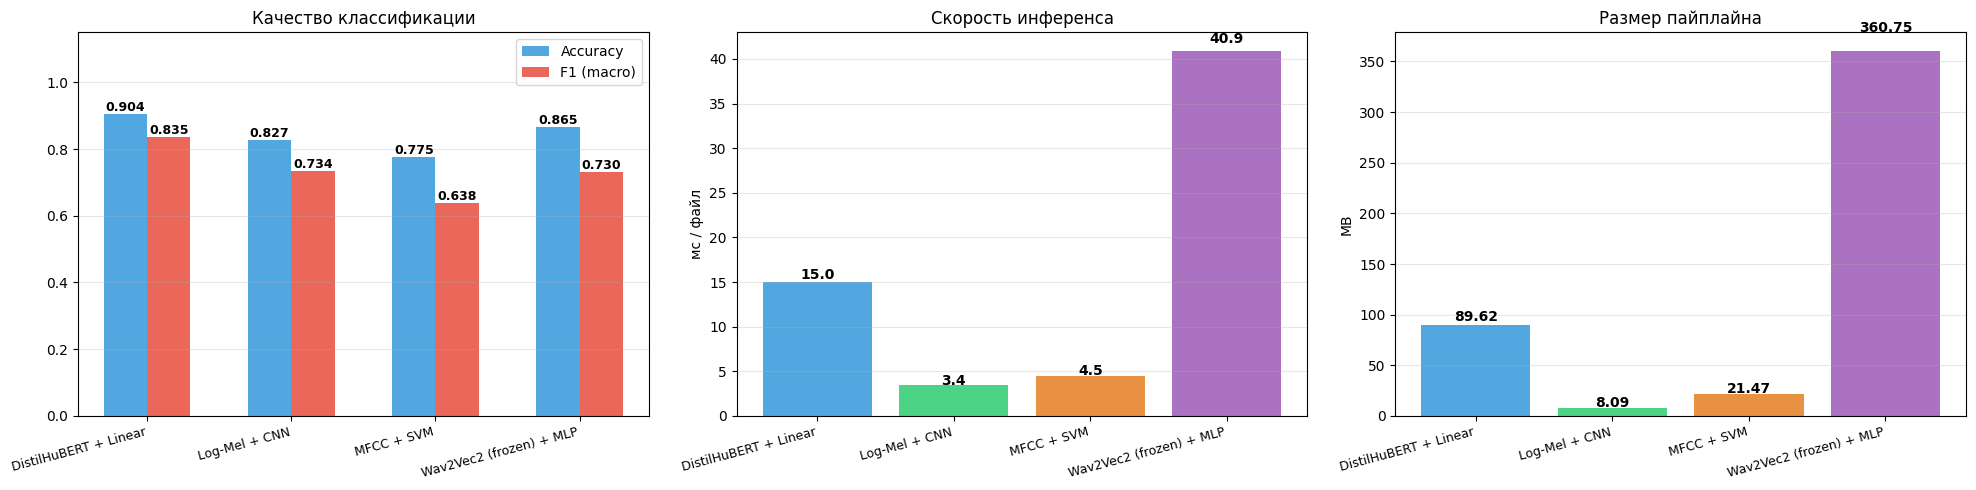

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
models = df["Модель"].tolist()
x = np.arange(len(models))
palette = ["#3498db", "#2ecc71", "#e67e22", "#9b59b6"]
colors = palette[:len(models)]

# ── Качество ──
w = 0.3
b1 = axes[0].bar(x - w / 2, df["Accuracy"], w,
                  label="Accuracy", color="#3498db", alpha=0.85)
b2 = axes[0].bar(x + w / 2, df["F1 (macro)"], w,
                  label="F1 (macro)", color="#e74c3c", alpha=0.85)
axes[0].set_ylim(0, 1.15)
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, fontsize=9, rotation=15, ha="right")
axes[0].set_title("Качество классификации")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)
for b in list(b1) + list(b2):
    axes[0].text(
        b.get_x() + b.get_width() / 2, b.get_height() + 0.01,
        f"{b.get_height():.3f}", ha="center", fontsize=9, fontweight="bold",
    )

# ── Скорость инференса ──
b3 = axes[1].bar(x, df["Инференс (мс/файл)"], color=colors, alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, fontsize=9, rotation=15, ha="right")
axes[1].set_ylabel("мс / файл")
axes[1].set_title("Скорость инференса")
axes[1].grid(axis="y", alpha=0.3)
for b in b3:
    axes[1].text(
        b.get_x() + b.get_width() / 2, b.get_height() * 1.02,
        f"{b.get_height():.1f}", ha="center", fontsize=10, fontweight="bold",
    )

# ── Размер пайплайна ──
b4 = axes[2].bar(x, df["Пайплайн (MB)"], color=colors, alpha=0.85)
axes[2].set_xticks(x)
axes[2].set_xticklabels(models, fontsize=9, rotation=15, ha="right")
axes[2].set_ylabel("MB")
axes[2].set_title("Размер пайплайна")
axes[2].grid(axis="y", alpha=0.3)
for b in b4:
    axes[2].text(
        b.get_x() + b.get_width() / 2, b.get_height() * 1.05,
        f"{b.get_height():.2f}", ha="center", fontsize=10, fontweight="bold",
    )

plt.tight_layout()
plt.show()

In [40]:
best_acc = df.loc[df["Accuracy"].idxmax()]
best_f1 = df.loc[df["F1 (macro)"].idxmax()]
fastest = df.loc[df["Инференс (мс/файл)"].idxmin()]
smallest = df.loc[df["Пайплайн (MB)"].idxmin()]

print("=" * 60)
print("Краткий анализ")
print("=" * 60)
print(f"• Лучшее качество (Accuracy): {best_acc['Модель']} — {best_acc['Accuracy']:.4f}")
print(f"• Лучшее качество (F1 macro): {best_f1['Модель']} — {best_f1['F1 (macro)']:.4f}")
print(f"• Самый быстрый инференс:    {fastest['Модель']} — {fastest['Инференс (мс/файл)']:.1f} мс/файл")
print(f"• Самый компактный пайплайн: {smallest['Модель']} — {smallest['Пайплайн (MB)']:.2f} MB")
print()
print("Выводы:")
print("• Pretrained-аудио-энкодеры (DistilHuBERT, Wav2Vec2) выигрывают по качеству — ")
print("  благодаря богатым представлениям, выученным на больших корпусах речи.")
print("• Fine-tuning Wav2Vec2 потенциально превосходит замороженный DistilHuBERT, ")
print("  но платит размером пайплайна (~360 MB против ~90 MB) и скоростью инференса.")
print("• Log-Mel + CNN — компромисс: компактная модель и быстрый инференс при умеренном качестве.")
print("• MFCC + SVM на дисбалансе классов проваливается на minority-классе (Neutral),")
print("  предсказывая почти всегда Emotional — низкий macro-F1.")

Краткий анализ
• Лучшее качество (Accuracy): DistilHuBERT + Linear — 0.9044
• Лучшее качество (F1 macro): DistilHuBERT + Linear — 0.8348
• Самый быстрый инференс:    Log-Mel + CNN — 3.4 мс/файл
• Самый компактный пайплайн: Log-Mel + CNN — 8.09 MB

Выводы:
• Pretrained-аудио-энкодеры (DistilHuBERT, Wav2Vec2) выигрывают по качеству — 
  благодаря богатым представлениям, выученным на больших корпусах речи.
• Fine-tuning Wav2Vec2 потенциально превосходит замороженный DistilHuBERT, 
  но платит размером пайплайна (~360 MB против ~90 MB) и скоростью инференса.
• Log-Mel + CNN — компромисс: компактная модель и быстрый инференс при умеренном качестве.
• MFCC + SVM на дисбалансе классов проваливается на minority-классе (Neutral),
  предсказывая почти всегда Emotional — низкий macro-F1.
